---
title: "Airbnb in NYC"
subtitle: "DATA 608 Spring 2025 - Story 4"
author: "Stephanie Chiang"
format: revealjs
jupyter: python3
execute:
  echo: false
  output: true
---

## Introduction

Using this [dataset](https://insideairbnb.com/) on the Airbnb listings in New York City, we will be examining some factors that have a positive effect on revenue for their hosts.

To begin with, both the revenue and price data contain some extreme outliers. In order to get a better sense of these interactions, the highest values (over 1000) can be dropped for a more effective analysis of the most common types of listings.

In [11]:
#| output: false

import pandas as pd
import math

# import the data
ab_raw = pd.read_csv("nyc_airbnb_listings.csv")
ab_raw.columns

/var/folders/8g/v1hprjvn28l43wv8d77g185h0000gn/T/ipykernel_1820/3692380291.py:7: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  ab_raw = pd.read_csv("nyc_airbnb_listings.csv")


Index(['...1', 'id', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighborhood',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated',
       'has_availability', 'number_of_reviews', 'number_of_reviews_ltm',
       'first_review', 'last_review', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_co

In [110]:
#| output: false

# Drop outliers in the price_per_accommodates and revenue columns

ab = ab.sort_values(by='price_per_accommodates', ascending=False)
ab = ab[ab['price_per_accommodates'] < 1000]
print(ab['price_per_accommodates'].head())

ab = ab.sort_values(by='revenue', ascending=False)
ab = ab[ab['revenue'] < 1000]
print(ab['revenue'].head())

1258     999.500000
31639    951.000000
30343    933.333333
37440    927.000000
11548    900.000000
Name: price_per_accommodates, dtype: float64
35192    999.000000
35691    999.000000
35191    999.000000
32895    994.854545
23192    989.307692
Name: revenue, dtype: float64


## What makes an airbnb profitable?

The majority of NYC listings have prices of $100 or less per guest per night and are concentrated in Manhattan and Brooklyn, which confirms the importance of price and location to prospective guests.

Also of note, most revenues fall in the range of $200 or less. This would be a great baseline for prospective hosts to aim for in entering the Airbnb space.

---

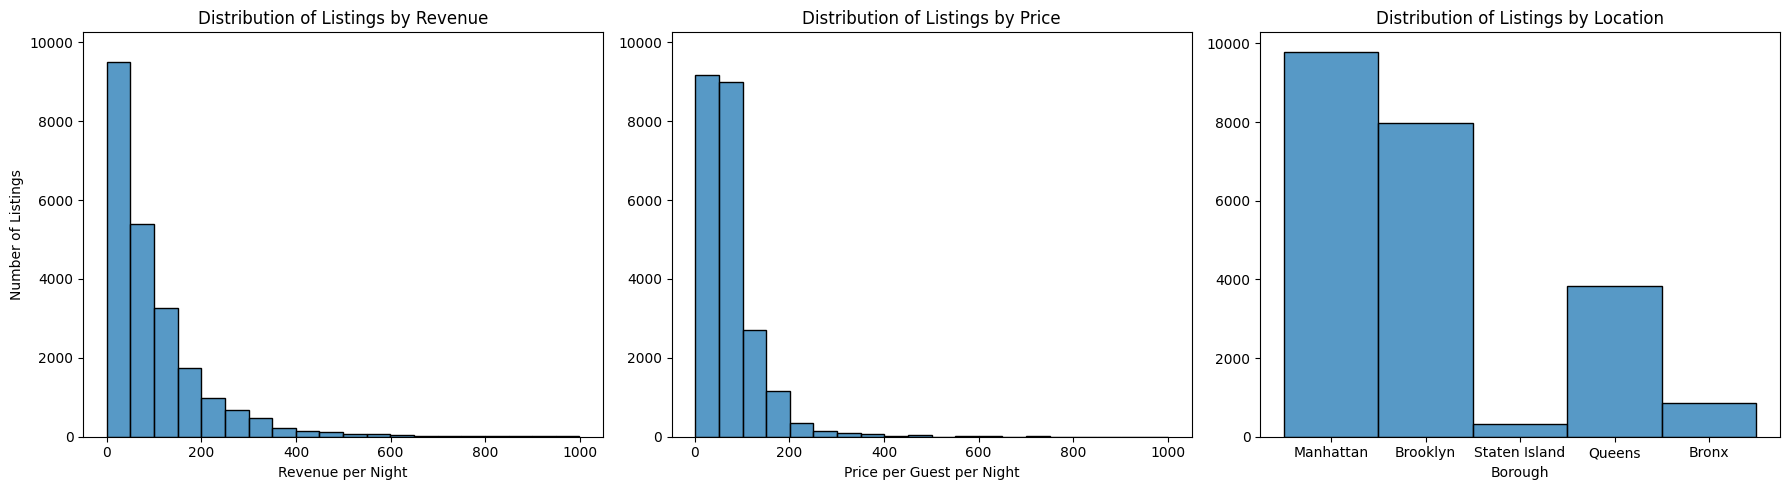

In [ ]:
#| output-location: slide

import matplotlib.pyplot as plt
import seaborn as sns

# Exploration of the data
# Overall distributions of listings

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(ab['revenue'], bins=20, ax=ax[0])
ax[0].set_title('Distribution of Listings by Revenue')
ax[0].set_xlabel('Revenue per Night')
ax[0].set_ylabel('Number of Listings')
ax[0].set_ylim(0, 10250)

sns.histplot(ab['price_per_accommodates'], bins=20, ax=ax[1])
ax[1].set_title('Distribution of Listings by Price')
ax[1].set_xlabel('Price per Guest per Night')
ax[1].set_ylabel('')
ax[1].set_ylim(0, 10250)

sns.histplot(ab['neighbourhood_group_cleansed'], bins=30, ax=ax[2])
ax[2].set_title('Distribution of Listings by Location')
ax[2].set_xlabel('Borough')
ax[2].set_ylabel('')

plt.tight_layout()
plt.show()

## Location location location

It will come as no surprise that the occupancy rates for the previous year and the revenue earned are higher in Manhattan and Brooklyn than in the other boroughs, even though the prices are also higher. Guests value the convenience of being close to attractions and businesses, and are willing to pay for it.

---

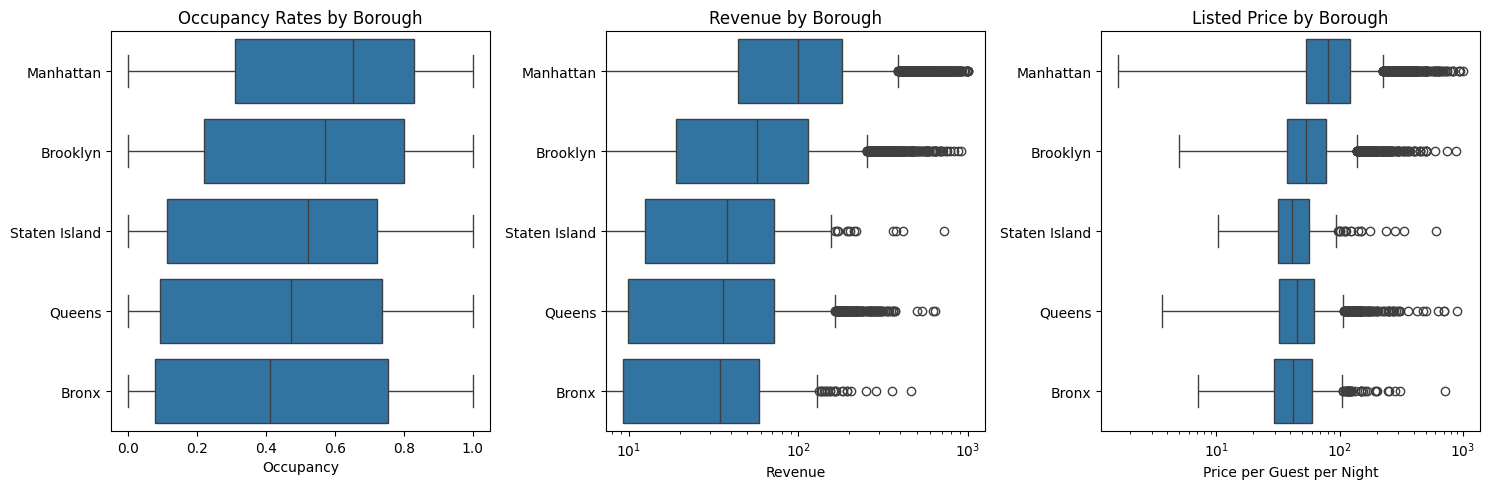

In [112]:
#| output-location: slide

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=ab, y='neighbourhood_group_cleansed', x='occupancy', ax=ax[0])
ax[0].set_title('Occupancy Rates by Borough')
ax[0].set_ylabel('')
ax[0].set_xlabel('Occupancy')

sns.boxplot(data=ab, y='neighbourhood_group_cleansed', x='revenue', ax=ax[1])
ax[1].set_title('Revenue by Borough')
ax[1].set_ylabel('')
ax[1].set_xlabel('Revenue')
ax[1].set_xscale('log')

sns.boxplot(data=ab, y='neighbourhood_group_cleansed', x='price_per_accommodates', ax=ax[2])
ax[2].set_title('Listed Price by Borough')
ax[2].set_ylabel('')
ax[2].set_xlabel('Price per Guest per Night')
ax[2].set_xscale('log')

plt.tight_layout()
plt.show()

## Price

The price of a listing per guest per night is a major factor in determining the revenue earned by the host, with a fairly linear relationship observed. Since it can be relatively easy in some instances to increase the number of guests in a unit (replacing a couch with a 2-person a sofa bed, for example), the gain in revenue can be significant. 

---

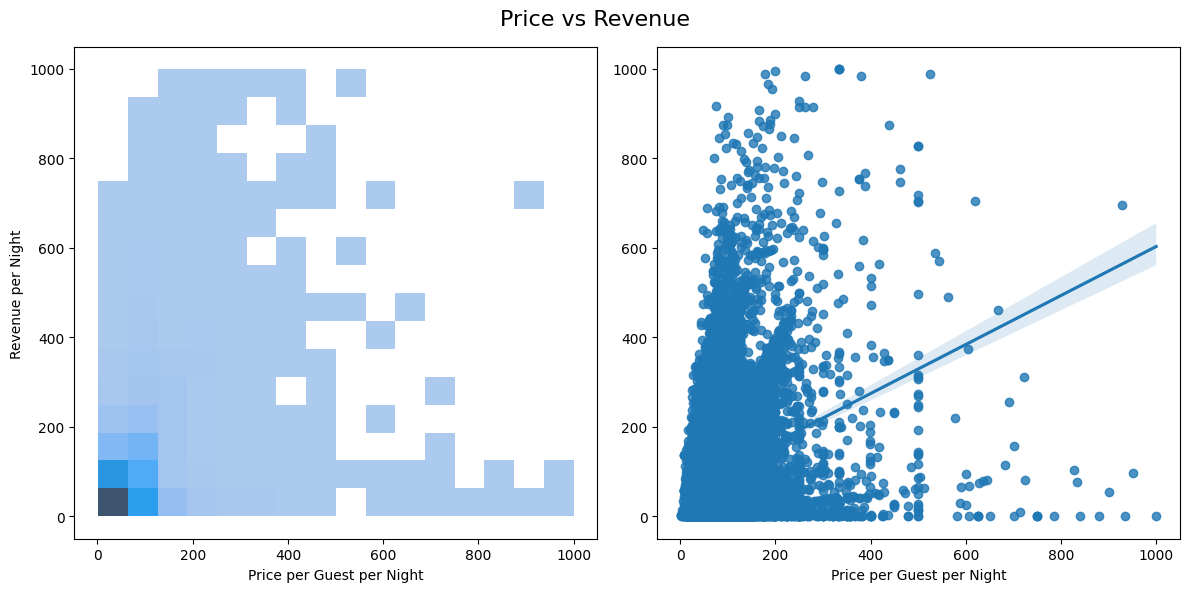

In [113]:
#| output-location: slide
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(data=ab, x='price_per_accommodates', y='revenue', bins=16, pmax=0.9, ax=ax[0])
ax[0].set_xlabel('Price per Guest per Night')
ax[0].set_ylabel('Revenue per Night')

sns.regplot(data=ab, x='price_per_accommodates', y='revenue', ax=ax[1])
ax[1].set_xlabel('Price per Guest per Night')
ax[1].set_ylabel('')

fig.suptitle('Price vs Revenue', fontsize=16)

plt.tight_layout()
plt.show()

## Number of Guests

If the number of guests accommodated is increased, the revenue earned by the host can also be expected to increase. This speaks to the appeal of Airbnb as an more accessible option for large groups and families over hotels, which often have a maximum of 4 guests per room.

However, this increase can only go up to Airbnb's maximum of 16 guests, with the peak of revenues at 14 guests before dropping sharply. (Which may have something to do with the notoriously small size of Manhattan apartments!)

---

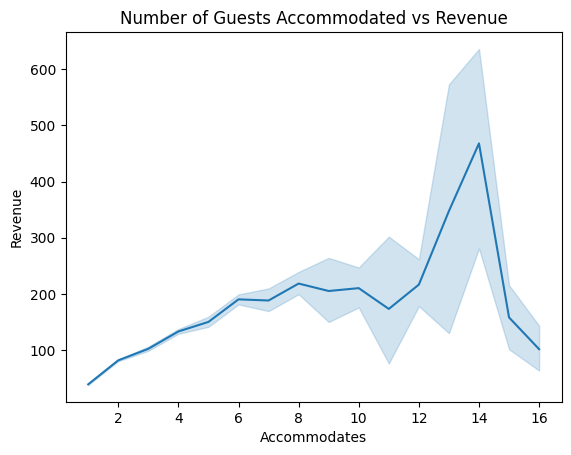

In [116]:
#| output-location: slide

sns.lineplot(data=ab, x='accommodates', y='revenue')
plt.title('Number of Guests Accommodated vs Revenue')
plt.xlabel('Accommodates')
plt.ylabel('Revenue')
plt.show()


## Conclusion

The data shows the importance of location and price to guests seeking Airbnbs in the NYC area. This suggests that potential hosts should be sought in Manhattan and Brooklyn, and that accommodation limits for units can be adjusted to increase prices and maximize revenue.